<a id="top"></a>
# Chapter 5 — Pulses, retention and neuromorphic use

**MemrisTec Compact Models — Memristor Physics from Paper to Code** · chapter 5 of 6

[◀ 4 Filamentary switching: Stanford–PKU and Yakopcic](Memristec_04_Filamentary_Switching.ipynb) · [Contents of the book](README.md) · [6 Benchmarking, numerics, fitting and the MemrisTec library ▶](Memristec_06_Benchmarking_and_the_Library.ipynb)

**In this chapter**

- [§17 Pulse programming: potentiation and depression](#sec-17)
- [§18 Linearity and symmetry of the conductance update](#sec-18)
- [§19 Retention and volatility](#sec-19)
- [§20 Hand-off to neuromorphic frameworks](#sec-20)

All chapters: [0](Memristec_00_Introduction.ipynb) · [1](Memristec_01_State_Controlled_Resistor.ipynb) · [2](Memristec_02_Linear_Ion_Drift_and_Windows.ipynb) · [3](Memristec_03_Threshold_Switching_VTEAM.ipynb) · [4](Memristec_04_Filamentary_Switching.ipynb) · [5](Memristec_05_Pulses_and_Neuromorphic_Use.ipynb) · [6](Memristec_06_Benchmarking_and_the_Library.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–26), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in MEMRISTEC_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("MEMRISTEC_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "memristec_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import memristec_tools as mt
from memristec_tools import (LinearIonDrift, Yakopcic2013, VTEAM2015, StanfordPKU2016, MODELS,
                             simulate, iv_sweep, loop_metrics, dynamic_route_map,
                             pulse_train, pulse_response, sine, triangular, rectangular)

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 17}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("memristec-skill", mt.__version__, "| numpy", np.__version__, "| chapter 5")
t_chapter_start = time.time()

memristec-skill 0.2.0 | numpy 2.5.2 | chapter 5


<a id="sec-17"></a>

## 17. Pulse programming: potentiation and depression

Memories and synapses are not driven by sines but by **pulses**: identical voltage pulses that
each move the state a little, with a small read voltage in between. A train of pulses that
raises the conductance is a *potentiation* (long-term potentiation, LTP, in the synaptic
vocabulary); a train that lowers it is a *depression* (LTD). `pulse_response` applies such a
train and reads the conductance after every pulse. The three model families give three
different curves: VTEAM moves the state by a fixed amount per pulse (rectangular window),
Yakopcic saturates within a few pulses (its exponential rate), the Stanford–PKU model needs
several pulses to close its gap and then jumps.

Mind the sign conventions: for VTEAM potentiation needs pulses *below* $v_{\rm on}$ (negative),
for the other two it needs positive pulses.

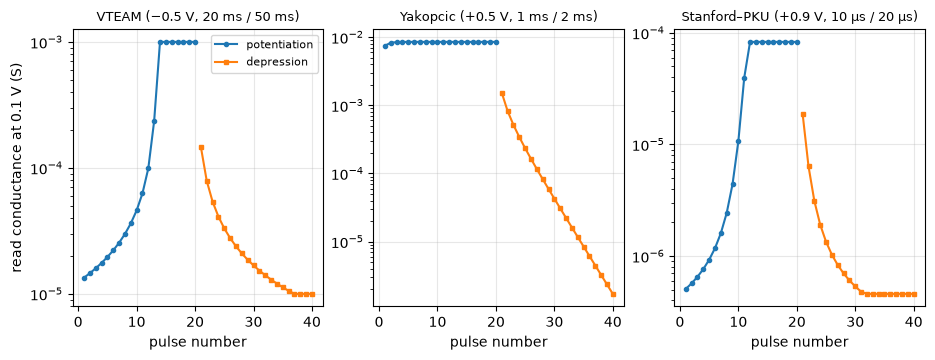

[PASS] VTEAM: potentiation raises G monotonically, depression lowers it
[PASS] VTEAM: 20 pulses of 20 ms at 0.5 V overdrive traverse the whole state range
[PASS] Yakopcic: saturated by pulse 10 (G changes < 0.1 % afterwards)
[PASS] Stanford–PKU: the state closes monotonically and reaches x = 1 — x after pulses 1, 5, 10, 20: 0.02, 0.14, 0.61, 1.00


True

In [2]:
cases = {
    "VTEAM (−0.5 V, 20 ms / 50 ms)":            (VTEAM2015(x0=0.8),      -0.5, 0.02, 0.05,  VTEAM2015(x0=0.0),      +0.5),
    "Yakopcic (+0.5 V, 1 ms / 2 ms)":           (Yakopcic2013(x0=0.2),   +0.5, 1e-3, 2e-3,  Yakopcic2013(x0=1.0),   -0.5),
    "Stanford–PKU (+0.9 V, 10 µs / 20 µs)":     (StanfordPKU2016(x0=0.0), +0.9, 1e-5, 2e-5, StanfordPKU2016(x0=1.0), -0.9),
}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
curves = {}
for ax, (name, (m_up, a_up, w, P, m_dn, a_dn)) in zip(axes, cases.items()):
    ltp = pulse_response(m_up, a_up, width=w, period=P, n_pulses=20)
    ltd = pulse_response(m_dn, a_dn, width=w, period=P, n_pulses=20)
    curves[name] = (ltp, ltd)
    ax.semilogy(np.arange(1, 21), ltp["G_after"], "o-", ms=3, label="potentiation")
    ax.semilogy(np.arange(21, 41), ltd["G_after"], "s-", ms=3, label="depression")
    ax.set_title(name, fontsize=9); ax.set_xlabel("pulse number")
axes[0].set_ylabel("read conductance at 0.1 V (S)"); axes[0].legend(fontsize=8)
show(fig)
caption("Read conductance after each of 20 potentiating and 20 depressing pulses for the three "
        "families. VTEAM changes the state by a constant step per pulse; Yakopcic saturates within "
        "five pulses; the Stanford–PKU gap closes gradually and then abruptly.")

v_ltp, v_ltd = curves["VTEAM (−0.5 V, 20 ms / 50 ms)"]
check("VTEAM: potentiation raises G monotonically, depression lowers it", np.all(np.diff(v_ltp["G_after"]) >= 0) and np.all(np.diff(v_ltd["G_after"]) <= 0))
check("VTEAM: 20 pulses of 20 ms at 0.5 V overdrive traverse the whole state range", v_ltp["x_after"][-1] == 0.0 and v_ltd["x_after"][-1] == 1.0)
y_ltp, _ = curves["Yakopcic (+0.5 V, 1 ms / 2 ms)"]
check("Yakopcic: saturated by pulse 10 (G changes < 0.1 % afterwards)", abs(y_ltp["G_after"][-1] - y_ltp["G_after"][9]) < 1e-3 * y_ltp["G_after"][-1])
s_ltp, _ = curves["Stanford–PKU (+0.9 V, 10 µs / 20 µs)"]
check("Stanford–PKU: the state closes monotonically and reaches x = 1", np.all(np.diff(s_ltp["x_after"]) >= 0) and s_ltp["x_after"][-1] == 1.0,
      f"x after pulses 1, 5, 10, 20: " + ", ".join(f"{s_ltp['x_after'][k]:.2f}" for k in (0, 4, 9, 19)))

<a id="sec-18"></a>

## 18. Linearity and symmetry of the conductance update

Learning algorithms that map weights onto conductances want the update **linear** (every
pulse adds the same $\Delta G$) and **symmetric** (potentiation and depression steps equal).
Physical devices rarely oblige. VTEAM's rectangular window gives a constant $\Delta x$ per pulse
— but the conductance $G = 1/(R_{\rm on} + (R_{\rm off} - R_{\rm on})x)$ is a hyperbola in $x$,
so $\Delta G$ per pulse shrinks as $G$ falls. The plot of $\Delta G$ against $G$ is the standard
nonlinearity diagnostic; a horizontal line would be ideal.

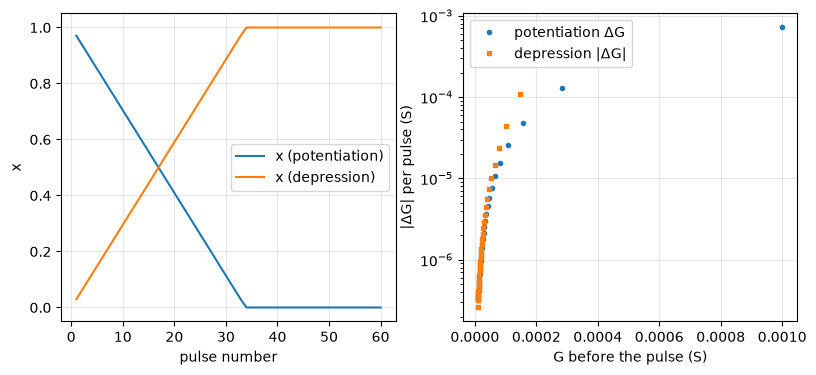

[PASS] Δx per pulse is constant while the state moves — Δx = -0.0295
[PASS] ΔG per pulse varies by more than a factor 10 over the range


True

In [3]:
ltp = pulse_response(VTEAM2015(x0=1.0), -0.5, width=0.01, period=0.02, n_pulses=60)
ltd = pulse_response(VTEAM2015(x0=0.0), +0.5, width=0.01, period=0.02, n_pulses=60)
dG_up, dG_dn = np.diff(ltp["G_after"]), -np.diff(ltd["G_after"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.0))
ax1.plot(np.arange(1, 61), ltp["x_after"], label="x (potentiation)"); ax1.plot(np.arange(1, 61), ltd["x_after"], label="x (depression)")
ax1.set_xlabel("pulse number"); ax1.set_ylabel("x"); ax1.legend()
ax2.semilogy(ltp["G_after"][1:], dG_up, "o", ms=3, label="potentiation ΔG"); ax2.semilogy(ltd["G_after"][1:], dG_dn, "s", ms=3, label="depression |ΔG|")
ax2.set_xlabel("G before the pulse (S)"); ax2.set_ylabel("|ΔG| per pulse (S)"); ax2.legend()
show(fig)
caption("VTEAM under 60 pulses of 10 ms at ±0.5 V. Left: the state moves by a constant step per "
        "pulse in both directions (rectangular window). Right: the conductance step is not "
        "constant — it grows with G because G is a hyperbola in x — the nonlinearity a learning "
        "rule has to compensate.")
dx = np.diff(ltp["x_after"])
inner = ltp["x_after"][1:] > 0.0                           # pulses that did not run into the boundary
check("Δx per pulse is constant while the state moves", np.allclose(dx[inner], dx[inner][0], rtol=1e-6), f"Δx = {dx[inner][0]:+.4f}")
check("ΔG per pulse varies by more than a factor 10 over the range", dG_up[dG_up > 0].max() / dG_up[dG_up > 0].min() > 10)

<a id="sec-19"></a>

## 19. Retention and volatility

None of the three shipped models has a relaxation term: at zero voltage $\dot x = 0$ exactly,
so a programmed state is kept forever — ideal non-volatile memory, and an idealisation. Real
devices drift (retention loss) and some are deliberately **volatile**: the NbO$_2$ threshold
switches of Pickett & Williams and Kumar & Williams relax back to the insulating state when the
current stops, because their state is a temperature. Those models live in the MemrisTec
library's `Threshold_Switching_*` folders and, having no clean-room version here yet, are
reachable only through the adapter (chapter 6). The check below is therefore trivial by
construction; it is here so that a future model with a decay term shows up as a change.

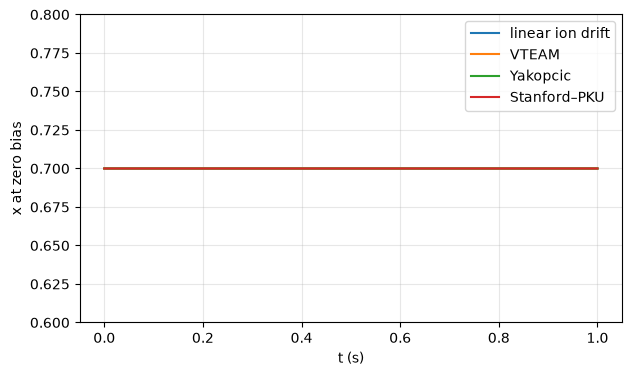

[PASS] no model loses state at zero bias


True

In [4]:
t = np.linspace(0.0, 1.0, 2001)
hold = np.zeros_like(t)
fig, ax = plt.subplots()
kept = {}
for name, m in [("linear ion drift", LinearIonDrift(x0=0.7)), ("VTEAM", VTEAM2015(x0=0.7)),
                ("Yakopcic", Yakopcic2013(x0=0.7)), ("Stanford–PKU", StanfordPKU2016(x0=0.7))]:
    r = simulate(m, t, hold)
    kept[name] = r.x[-1]
    ax.plot(t, r.x, label=name)
ax.set_xlabel("t (s)"); ax.set_ylabel("x at zero bias"); ax.set_ylim(0.6, 0.8); ax.legend()
show(fig)
caption("One second at zero bias: every shipped model keeps its state exactly — there is no "
        "relaxation term in any of the four equation sets.")
check("no model loses state at zero bias", all(x == 0.7 for x in kept.values()))

<a id="sec-20"></a>

## 20. Hand-off to neuromorphic frameworks

Frameworks such as aihwkit and snnTorch do not integrate device ODEs; they need a **conductance
update rule** $G \leftarrow G + \Delta G(G, \text{pulse})$ and a read model $i = G\,v$. Both come
out of `pulse_response`: the potentiation and depression curves of §17–18 *are* the lookup
tables. The cell below programs a 4×4 crossbar of VTEAM devices by pulse count (sixteen
21 ms pulses of −0.5 V take the state from $R_{\rm off}$ to within 1 % of $R_{\rm on}$, a
four-bit weight), then performs a vector–matrix multiplication by reading all rows at once.
This is the interface the MemrisTec README promises for aihwkit / snnTorch, and what a
library licence (finding B-1) would unlock.

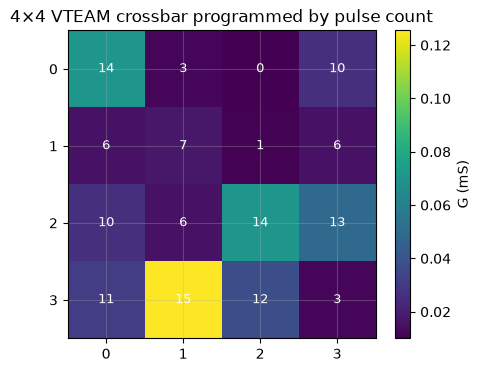

[PASS] the programming table is monotone in the pulse count
[PASS] i_out equals G·v (Kirchhoff's current law along each row)
[PASS] 16 pulses take G from 1/R_off to more than 50× that (x within 1 % of R_on, not clipped) — G: 1.0e-05 → 5.4e-04 S, final x = 0.0085


True

In [5]:
n_levels = 16
table = pulse_response(VTEAM2015(x0=1.0), -0.5, width=0.021, period=0.05, n_pulses=n_levels)   # Δx ≈ 0.062 per pulse
G_of_pulses = np.concatenate([[VTEAM2015(x0=1.0).current(1.0, 0.1) / 0.1], table["G_after"]])   # index = pulses applied

rng = np.random.default_rng(2026)
pulses = rng.integers(0, n_levels + 1, size=(4, 4))
G = G_of_pulses[pulses]                                   # programmed crossbar conductances
v_in = np.array([0.1, 0.05, 0.0, 0.08])                    # read voltages on the columns
i_out = G @ v_in                                           # currents summed along the rows

fig, ax = plt.subplots(figsize=(5.0, 4.0))
im = ax.imshow(G * 1e3, cmap="viridis"); plt.colorbar(im, ax=ax, label="G (mS)")
for (r_, c_), p in np.ndenumerate(pulses):
    ax.text(c_, r_, str(p), ha="center", va="center", color="w", fontsize=9)
ax.set_title("4×4 VTEAM crossbar programmed by pulse count"); ax.set_xticks(range(4)); ax.set_yticks(range(4))
show(fig)
caption("A crossbar of VTEAM devices, each programmed by the number of −0.5 V, 21 ms pulses "
        "written on it (0–16); the colour is the resulting read conductance. Reading all columns "
        "at once computes the vector–matrix product i = G·v.")
check("the programming table is monotone in the pulse count", np.all(np.diff(G_of_pulses) > 0))
check("i_out equals G·v (Kirchhoff's current law along each row)", np.allclose(i_out, np.sum(G * v_in, axis=1)))
check("16 pulses take G from 1/R_off to more than 50× that (x within 1 % of R_on, not clipped)",
      np.isclose(G_of_pulses[0], 1e-5) and G_of_pulses[-1] / G_of_pulses[0] > 50 and 0.0 < table["x_after"][-1] < 0.01,
      f"G: {G_of_pulses[0]:.1e} → {G_of_pulses[-1]:.1e} S, final x = {table['x_after'][-1]:.4f}")

### Exercises for chapter 5

**5.1** For VTEAM, a 20 ms pulse at 0.5 V moves the state by $\Delta x = 0.2 \cdot 10 \cdot
(0.5/0.3 - 1)^3 \approx 0.059$. Which amplitude gives the same $\Delta x$ with a 10 ms pulse?
(Cubic law: $(A/0.3 - 1)^3 = 2\,(0.5/0.3 - 1)^3$.)

**5.2** Reads must not write. Show that 10 000 read pulses of 0.1 V leave a Yakopcic device
untouched, and find the read amplitude above which they do not.

In [6]:
# 5.1 — the cubic law makes the two integrals equal; on the grid they agree to 0.5 %, the residual
#       being the RK4 half-step at each pulse edge, where the interpolated voltage (0.25 V) lies
#       inside the dead band, so every edge integrates only 1/6 of a step (references/pitfalls.md, 12)
A = 0.3 * (1 + 2 ** (1 / 3) * (0.5 / 0.3 - 1))
dx_20 = pulse_response(VTEAM2015(x0=0.5), 0.5, width=0.02, period=0.05, n_pulses=1)["x_after"][0] - 0.5
dx_10 = pulse_response(VTEAM2015(x0=0.5), A, width=0.01, period=0.05, n_pulses=1)["x_after"][0] - 0.5
check("5.1 A ≈ 0.552 V gives the same Δx in half the time (to 1 %)", abs(dx_10 / dx_20 - 1) < 1e-2,
      f"A = {A:.3f} V, Δx(20 ms, 0.5 V) = {dx_20:.5f}, Δx(10 ms, {A:.3f} V) = {dx_10:.5f}")

# 5.2 — Yakopcic's threshold is V_p = 0.16 V: reads below it are free, above it they write
t = np.linspace(0.0, 10.0, 200001)
safe = simulate(Yakopcic2013(x0=0.5), t, pulse_train(t, 0.1, width=0.5e-3, period=1e-3, n_pulses=10000))
unsafe = simulate(Yakopcic2013(x0=0.5), t, pulse_train(t, 0.2, width=0.5e-3, period=1e-3, n_pulses=10000))
check("5.2 0.1 V reads are free, 0.2 V reads write", safe.x[-1] == 0.5 and unsafe.x[-1] != 0.5,
      f"x after 10 000 reads: 0.1 V → {safe.x[-1]:.4f}, 0.2 V → {unsafe.x[-1]:.4f}")

[PASS] 5.1 A ≈ 0.552 V gives the same Δx in half the time (to 1 %) — A = 0.552 V, Δx(20 ms, 0.5 V) = 0.05895, Δx(10 ms, 0.552 V) = 0.05864


[PASS] 5.2 0.1 V reads are free, 0.2 V reads write — x after 10 000 reads: 0.1 V → 0.5000, 0.2 V → 1.0000


True

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 5 — checks passed : {_CHECKS['pass']}")
print(f"chapter 5 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 5 — checks passed : 12
chapter 5 — checks failed : 0
wall time                 : 11 s
Every quantitative claim in this notebook was verified in this run.
